In [1]:
from pprint import pprint
import numpy as np
import re
import numpy as np
import pathlib
import sys
import shutil
import cf

import os, glob

from tqdm import tqdm
import jupyter_black
import seaborn as sns
import netCDF4
import os
import copy
from pathlib import Path
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"
jupyter_black.load()

In [2]:
times = [59 + 16 / 60, 16 + 16 / 60, 6]

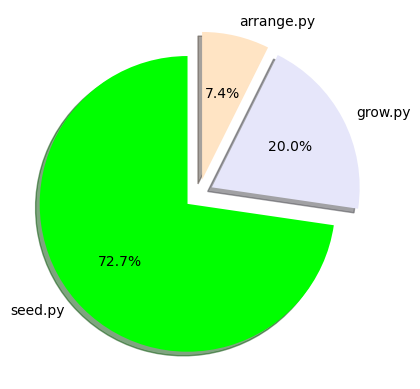

In [3]:
import matplotlib.pyplot as plt

labels = ("seed.py", "grow.py", "arrange.py")

explode = [0.1, 0.1, 0.1]

fig, ax = plt.subplots()
ax.pie(
    times,
    explode=explode,
    labels=labels,
    autopct="%1.1f%%",
    shadow=True,
    startangle=90,
    colors=["lime", "lavender", "bisque"],
)

plt.show();

# Example of reading in CFA file for particular times/dates/variables etc

In [4]:
quarter_map = {
    "01": "01",
    "02": "01",
    "03": "01",
    "04": "04",
    "05": "04",
    "06": "04",
    "07": "07",
    "08": "07",
    "09": "07",
    "10": "10",
    "11": "10",
    "12": "10",
}

In [14]:
f = cf.read(
    glob.glob("./CF-1.13_grown_CANARI_27_db301_atmos_65years_batches.cfa"),
)

y = np.random.randint(1950, 2014)
m = np.random.randint(1, 9)
d = np.random.randint(1, 30)
print(f"The date is {y:04d}-{m:02d}-{d:02d}")

target_field = f.select_by_property(
    standard_name="surface_temperature", interval_operation="3 h"
)[0].subspace(T=cf.wi(cf.dt(y, m, d, 0, 0), cf.dt(y, m + 3, d, 23, 59)))

pprint("File name or names...")
pprint(target_field.data.get_filenames())
pprint("The unique ancillary batch or batches are...")
np.unique(
    target_field.constructs.filter(
        filter_by_property={"long_name": re.compile(".*jdma.*", re.I)}
    )
    .value()
    .array
).tolist()

The date is 1965-06-29
'File name or names...'
{'db301a_13_3hr_pt__196506-196506.nc',
 'db301a_13_3hr_pt__196507-196507.nc',
 'db301a_13_3hr_pt__196508-196508.nc',
 'db301a_13_3hr_pt__196509-196509.nc'}
'The unique ancillary batch or batches are...'


['13511', '13531']

In [16]:
for _m in [m, m + 3]:

    m_formatted = f"{_m:02d}"
    search_pattern = str(y) + quarter_map[m_formatted]

    for file in glob.glob("/home/users/jonnyhtw/canari/docs/hist2/*db301*"):
        for line in open(file):
            if search_pattern in line:
                print(line)

    62	   13511 jrobson          canari           u-db301/19650401 elastictape      2023-12-19 18:55  ON_STORAGE 

    63	   13531 jrobson          canari           u-db301/19650701 elastictape      2023-12-20 00:16  ON_STORAGE 

